In [12]:
import random

import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

In [14]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

data_base_path = "./data/" if IN_COLAB else "asl_data/"

## Load data

In [15]:
train_df = pd.read_csv(data_base_path + "train.csv")
val_df = pd.read_csv(data_base_path + "val.csv")
test_df = pd.read_csv(data_base_path + "test.csv")

In [16]:
def label_to_letter(lbl):
    letter_code = ord('A') + int(lbl)
    return chr(letter_code) if letter_code < ord('J') else chr(letter_code + 1)

def show(img, lbl):
    i = img.reshape(28,28)
    plt.figure(figsize=(5,5))
    plt.title(label_to_letter(lbl), fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(i, cmap='gray')

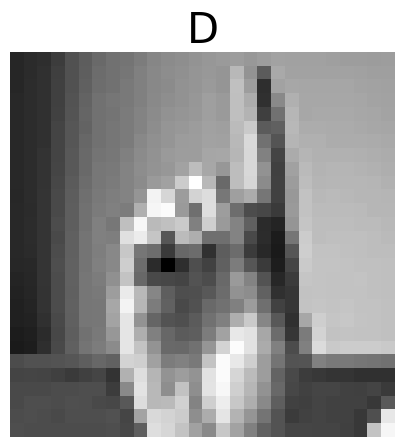

In [17]:
rnd_idx = random.choice(train_df.index.tolist())
image = train_df.iloc[rnd_idx].drop('label').values
label = train_df.iloc[rnd_idx]['label']
show(image, label)

## Preparing dataset

In [18]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1

class AslDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()
        y_df = x_df.pop('label')
        x_df = x_df.values / 255
        x_df = x_df.reshape(-1, IMG_CHANNELS, IMG_WIDTH, IMG_HEIGHT)
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).long().to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [19]:
train_data = AslDataset(train_df)
val_data = AslDataset(val_df)
test_data = AslDataset(test_df)

In [20]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

## Training functions

In [21]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

In [22]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

In [23]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

## Training the models

In [24]:
model_fcnn = nn.Sequential(
    nn.Flatten(),
    nn.Linear(IMG_HEIGHT * IMG_WIDTH, 512),
    nn.ReLU(),
    nn.Dropout(.3),

    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_fcnn = model_fcnn.to(device)

In [25]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_fcnn.parameters())

fcnn_res = train(model_fcnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [05:40<00:00, 17.02s/epoch, train_acc=0.8935, train_loss=0.3179, val_acc=0.7504, val_loss=0.7915]


In [26]:
fcnn_test_loss, fcnn_test_acc = test(model_fcnn, test_loader, loss_function)

## CNN model

In [27]:
model_cnn = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  # 25 x 28 x 28
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 14 x 14

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  # 50 x 14 x 14
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 50 x 7 x 7

    nn.Conv2d(50, 75, 3, stride=1, padding=1),  # 75 x 7 x 7
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_cnn = model_cnn.to(device)

In [28]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [09:47<00:00, 29.38s/epoch, train_acc=0.9961, train_loss=0.0126, val_acc=0.9557, val_loss=0.3295]


In [29]:
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

Which model is better at classifying ASL images? El de CNN ya que tiene un accuracy mejor

Which model was faster to train? El de fully connected

In [37]:
def plot_learning_curves(fcnn_res, cnn_res):
    epochs = range(1, len(fcnn_res['train_loss']) + 1)

    plt.plot(epochs, fcnn_res['train_loss'], label="FCNN Train Loss")
    plt.plot(epochs, fcnn_res['val_loss'], label="FCNN Validation Loss")
    plt.plot(epochs, cnn_res['train_loss'], label="CNN Train Loss")
    plt.plot(epochs, cnn_res['val_loss'], label="CNN Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Learning Curves")
    plt.legend()
    plt.show()


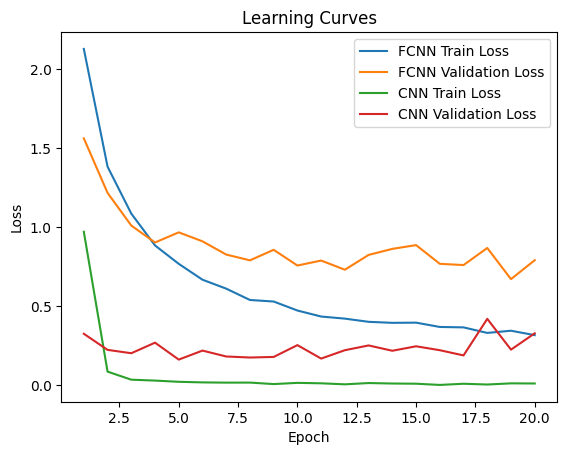

In [38]:
plot_learning_curves(fcnn_res, cnn_res)

How many trainable parameters does each model have? 

FCNN tiene 676888 y CNN tiene 403799

How do the models compare in terms of overfitting? Why do you think that is the case? FCNN es mas probable a tener overfitting ya que tiene mayor cantidad de parametros ademas de que no generaliza patrones a comparacion de CNN, la cual mantiene los lossess relativamente estables

## Final conclusions and remarks

Pude ver que la CNN es mejor clasificando imagenes que la FCNN, aunque esta sea mas rapida ademas de que es mas probable que tenga overfitting ya que tiene mas parametros, ademas de que no captura patrones espaciales a comparacion de CNN la cual tiene unas curvas de aprendizaje mas estables lo que muestra que es mejor generalizando patrones.